<a href="https://colab.research.google.com/github/NguyenVanDung123/Handwritten-Digit-Recognition-with-CNN/blob/main/CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/5
300/300 [==============================] - 55s 178ms/step - loss: 0.2523 - accuracy: 0.9301 - val_loss: 0.0660 - val_accuracy: 0.9800
Epoch 2/5
300/300 [==============================] - 49s 162ms/step - loss: 0.0652 - accuracy: 0.9803 - val_loss: 0.0546 - val_accuracy: 0.9831
Epoch 3/5
300/300 [==============================] - 51s 171ms/step - loss: 0.0463 - accuracy: 0.9864 - val_loss: 0.0458 - val_accuracy: 0.9853
Epoch 4/5
300/300 [==============================] - 47s 156ms/step - loss: 0.0352 - accuracy: 0.9889 - val_loss: 0.0425 - val_accuracy: 0.9866
Epoch 5/5
300/300 [==============================] - 48s 161ms/step - loss: 0.0294 - accuracy: 0.9910 - val_loss: 0.0323 - val_accuracy: 0.9894
Test loss: 0.032298505306243896
Test accuracy: 0.9894000291824341
1/1 [==============================] - 0s 81ms/step


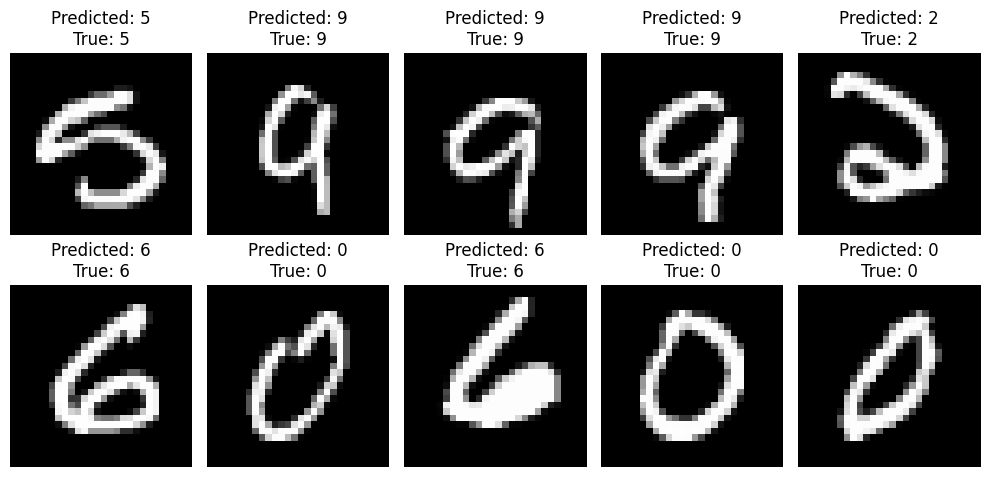

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical

# Bước 1: Tải và chuẩn bị dữ liệu MNIST
# Tải dữ liệu MNIST từ Keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Thêm kênh màu (1 kênh vì ảnh là grayscale) và chuẩn hóa dữ liệu
# Định dạng lại dữ liệu từ (samples, 28, 28) thành (samples, 28, 28, 1)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255

# One-hot encoding cho nhãn
# Chuyển đổi nhãn từ dạng số nguyên thành dạng one-hot
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Bước 2: Xây dựng mô hình CNN
# Khởi tạo mô hình Sequential
model = Sequential()

# Thêm lớp tích chập đầu tiên với 32 bộ lọc, kích thước kernel 3x3, và hàm kích hoạt ReLU
# input_shape là (28, 28, 1) do ảnh MNIST có kích thước 28x28 và 1 kênh màu (grayscale)
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Thêm lớp pooling với kích thước pool 2x2
model.add(MaxPooling2D(pool_size=(2, 2)))

# Thêm lớp tích chập thứ hai với 64 bộ lọc, kích thước kernel 3x3, và hàm kích hoạt ReLU
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))

# Thêm lớp pooling với kích thước pool 2x2
model.add(MaxPooling2D(pool_size=(2, 2)))

# Thêm lớp Flatten để chuyển đổi từ tensor 3D thành vector 1D
model.add(Flatten())

# Thêm lớp Dense với 128 đơn vị và hàm kích hoạt ReLU
model.add(Dense(128, activation='relu'))

# Thêm lớp đầu ra với 10 đơn vị (tương ứng với 10 lớp của MNIST) và hàm kích hoạt softmax
model.add(Dense(10, activation='softmax'))

# Compile mô hình
# Sử dụng optimizer Adam, hàm loss categorical_crossentropy và metric accuracy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Bước 3: Huấn luyện mô hình
# Huấn luyện mô hình với dữ liệu huấn luyện, trong 5 epochs và kích thước batch 200
model.fit(x_train, y_train, epochs=5, batch_size=200, validation_data=(x_test, y_test))

# Bước 4: Đánh giá mô hình
# Đánh giá mô hình trên tập dữ liệu kiểm tra
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# Bước 5: Dự đoán và hiển thị kết quả
# Lấy 10 ảnh ngẫu nhiên từ tập kiểm tra
indices = np.random.choice(len(x_test), 10, replace=False)
test_images = x_test[indices]
test_labels = y_test[indices]

# Dự đoán nhãn cho 10 ảnh này
predictions = model.predict(test_images)

# Hiển thị kết quả
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}\nTrue: {np.argmax(test_labels[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 32ms/step


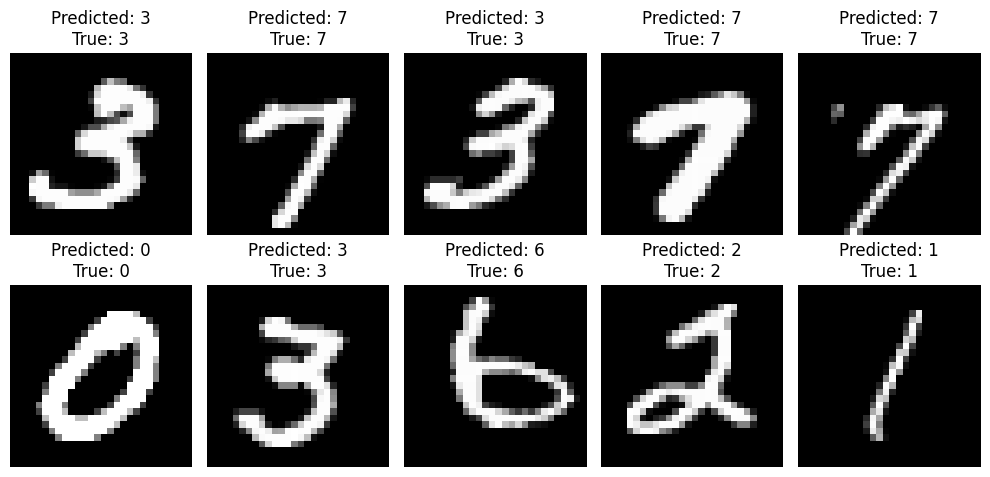

In [ ]:
# Bước 5: Dự đoán và hiển thị kết quả
# Lấy 10 ảnh từ tập test
indices = np.random.choice(len(x_test), 10, replace=False)
test_images = x_test[indices]
test_labels = y_test[indices]
predictions = model.predict(test_images)

# Hiển thị kết quả
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}\nTrue: {np.argmax(test_labels[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 34ms/step


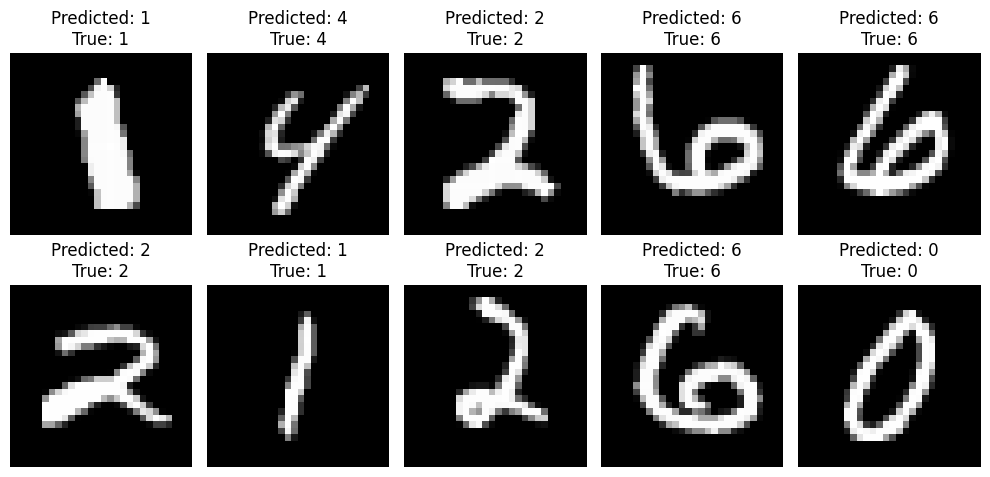

In [ ]:
# Bước 5: Dự đoán và hiển thị kết quả
# Lấy 10 ảnh từ tập test
indices = np.random.choice(len(x_test), 10, replace=False)
test_images = x_test[indices]
test_labels = y_test[indices]
predictions = model.predict(test_images)

# Hiển thị kết quả
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}\nTrue: {np.argmax(test_labels[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 22ms/step


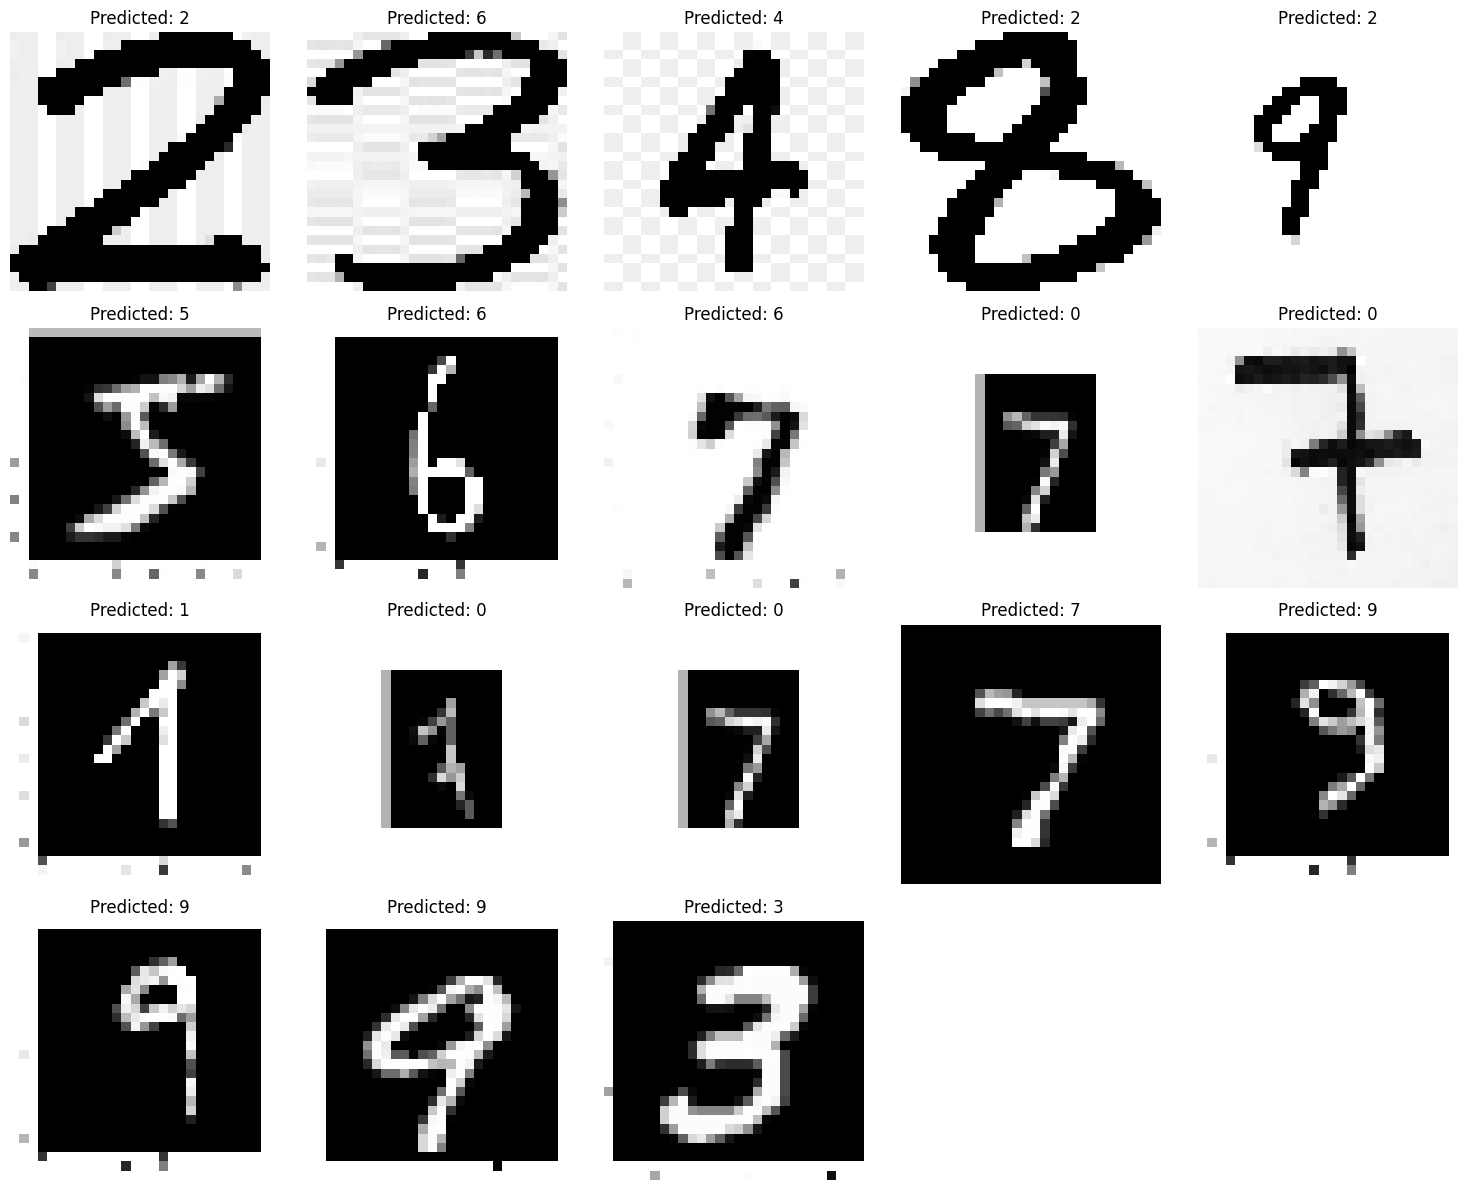

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2
def prepare_image(file_path):
    img = load_img(file_path, color_mode='grayscale', target_size=(28, 28))
    img = img_to_array(img)
    img = img.reshape(1, 28, 28, 1).astype('float32') / 255
    return img

# Đường dẫn đến ảnh từ bên ngoài
external_images = ['hai.jpg', 'ba.png', 'bon.png', 'tam.png', 'chin.png',
                   'nam.webp', 'sau.png', 'bay1.png', 'bay2.png', 'bay3.jpg', 'mot.png',
                   'bay_1.png', 'bay_2.png', 'bay_3.webp', 'chin_1.png', 'chin_2.png',
                   'chin_3.png', 'ba_1.png']

# Dự đoán và hiển thị kết quả
num_images_per_row = 5
num_rows = (len(external_images) + num_images_per_row - 1) // num_images_per_row

plt.figure(figsize=(15, num_rows * 3))
for i, img_path in enumerate(external_images):
    img = prepare_image(img_path)
    prediction = model.predict(img)
    plt.subplot(num_rows, num_images_per_row, i + 1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(prediction)}")
    plt.axis('off')

plt.tight_layout()
plt.show()